# 04. Feature Validation
## Digital Burnout International Dataset

- Kiểm tra mức độ phù hợp của từng chỉ báo Digital Burnout.
- Đánh giá mối liên hệ giữa các biến nghiên cứu với `burnout_risk` và `productivity_score`.
- Xác định các chỉ báo mạnh, trung bình và yếu trước khi xây dựng DBI Framework.
- Tạo bảng Feature Validation Summary làm đầu vào cho DBI Development và Modeling.


## Import thư viện

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Cleaned Dataset

Dataset đầu vào là dữ liệu đã được làm sạch từ notebook:

`02_cleaning_preprocessing.ipynb`


In [2]:
# Load cleaned dataset

file_path = "../../data/processed/international_dataset/digital_burnout_cleaned.csv"

df = pd.read_csv(file_path)

print("Cleaned dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Cleaned dataset loaded successfully.
Dataset shape: (5000000, 34)


## 2. Research Features Review

Phần này kiểm tra sự tồn tại của các biến nghiên cứu theo từng nhóm chỉ báo Digital Burnout.

Các nhóm gồm:

1. Burnout Symptoms  
2. Digital Exposure  
3. Cognitive Performance  
4. Sleep & Recovery  
5. Context Variables  

Mục tiêu:

- Đảm bảo các biến cần validation có tồn tại trong dataset.
- Mapping biến theo từng nhóm nghiên cứu.
- Chuẩn bị danh sách biến cho correlation và statistical validation.

In [3]:
# Define research feature groups

feature_groups = {
    "Burnout Symptoms": [
        "emotional_exhaustion",
        "stress_level",
        "mental_fatigue"
    ],
    "Digital Exposure": [
        "daily_screen_time",
        "social_media_hours",
        "doomscrolling_duration",
        "late_night_device_usage",
        "notification_count",
        "smartphone_unlocks",
        "app_switch_frequency"
    ],
    "Cognitive Performance": [
        "concentration_score",
        "distraction_frequency",
        "focus_sessions",
        "deep_work_hours",
        "task_completion_rate",
        "motivation_level"
    ],
    "Sleep & Recovery": [
        "sleep_hours",
        "sleep_quality"
    ],
    "Context Variables": [
        "work_mode",
        "device_usage_type"
    ]
}

target_variables = [
    "burnout_risk",
    "productivity_score"
]

In [4]:
# Check feature availability

feature_review_rows = []

for group_name, features in feature_groups.items():
    for feature in features:
        feature_review_rows.append({
            "construct_group": group_name,
            "indicator": feature,
            "available": feature in df.columns,
            "data_type": str(df[feature].dtype) if feature in df.columns else "Not available",
            "missing_count": df[feature].isnull().sum() if feature in df.columns else np.nan,
            "unique_values": df[feature].nunique() if feature in df.columns else np.nan
        })

feature_review = pd.DataFrame(feature_review_rows)

display(feature_review)

,construct_group,indicator,available,data_type,missing_count,unique_values
0,Burnout Symptoms,emotional_exhaustion,True,int64,0,10
1,Burnout Symptoms,stress_level,True,int64,0,10
2,Burnout Symptoms,mental_fatigue,True,int64,0,10
3,Digital Exposure,daily_screen_time,True,float64,0,171
4,Digital Exposure,social_media_hours,True,float64,0,121
5,Digital Exposure,doomscrolling_duration,True,float64,0,80
6,Digital Exposure,late_night_device_usage,True,int64,0,2
7,Digital Exposure,notification_count,True,int64,0,380
8,Digital Exposure,smartphone_unlocks,True,int64,0,285
9,Digital Exposure,app_switch_frequency,True,int64,0,240


In [5]:
# Prepare available feature lists

available_features = [
    row["indicator"]
    for _, row in feature_review.iterrows()
    if row["available"] == True
]

available_numeric_features = [
    col for col in available_features
    if pd.api.types.is_numeric_dtype(df[col])
]

available_categorical_features = [
    col for col in available_features
    if col not in available_numeric_features
]

available_targets = [
    col for col in target_variables
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

print("Available numeric features:")
print(available_numeric_features)

print("\nAvailable categorical features:")
print(available_categorical_features)

print("\nAvailable targets:")
print(available_targets)

Available numeric features:
['emotional_exhaustion', 'stress_level', 'mental_fatigue', 'daily_screen_time', 'social_media_hours', 'doomscrolling_duration', 'late_night_device_usage', 'notification_count', 'smartphone_unlocks', 'app_switch_frequency', 'concentration_score', 'distraction_frequency', 'focus_sessions', 'deep_work_hours', 'task_completion_rate', 'motivation_level', 'sleep_hours', 'sleep_quality']

Available categorical features:
['work_mode', 'device_usage_type']

Available targets:
['burnout_risk', 'productivity_score']


## 3. Correlation-based Validation

Phần này đánh giá mối quan hệ giữa từng chỉ báo định lượng với hai biến mục tiêu:

- `burnout_risk`
- `productivity_score`

Sử dụng hai loại correlation:

- Pearson Correlation: đo quan hệ tuyến tính.
- Spearman Correlation: đo quan hệ đơn điệu, phù hợp khi dữ liệu không phân phối chuẩn hoặc có outlier.

Lưu ý:

Correlation không chứng minh quan hệ nhân quả, nhưng giúp đánh giá mức độ liên hệ ban đầu của chỉ báo.

In [6]:
# Correlation validation function

def compute_correlation_validation(dataframe, features, targets):
    results = []
    
    for feature in features:
        for target in targets:
            valid_data = dataframe[[feature, target]].dropna()
            
            if valid_data.shape[0] < 3:
                continue
            
            pearson_corr, pearson_p = stats.pearsonr(
                valid_data[feature],
                valid_data[target]
            )
            
            spearman_corr, spearman_p = stats.spearmanr(
                valid_data[feature],
                valid_data[target]
            )
            
            results.append({
                "indicator": feature,
                "target": target,
                "pearson_correlation": pearson_corr,
                "pearson_p_value": pearson_p,
                "spearman_correlation": spearman_corr,
                "spearman_p_value": spearman_p,
                "absolute_pearson": abs(pearson_corr),
                "absolute_spearman": abs(spearman_corr)
            })
    
    return pd.DataFrame(results)


correlation_validation = compute_correlation_validation(
    df,
    available_numeric_features,
    available_targets
)

display(correlation_validation.sort_values(
    by=["target", "absolute_spearman"],
    ascending=[True, False]
))

,indicator,target,pearson_correlation,pearson_p_value,spearman_correlation,spearman_p_value,absolute_pearson,absolute_spearman
0,emotional_exhaustion,burnout_risk,0.511981,0.000000,0.509398,0.000000,0.511981,0.509398
2,stress_level,burnout_risk,0.382824,0.000000,0.376978,0.000000,0.382824,0.376978
6,daily_screen_time,burnout_risk,0.220783,0.000000,0.210659,0.000000,0.220783,0.210659
10,doomscrolling_duration,burnout_risk,0.200315,0.000000,0.192633,0.000000,0.200315,0.192633
12,late_night_device_usage,burnout_risk,0.158050,0.000000,0.154407,0.000000,0.158050,0.154407
22,distraction_frequency,burnout_risk,0.152152,0.000000,0.148415,0.000000,0.152152,0.148415
32,sleep_hours,burnout_risk,-0.129446,0.000000,-0.123721,0.000000,0.129446,0.123721
14,notification_count,burnout_risk,0.096691,0.000000,0.094314,0.000000,0.096691,0.094314
26,deep_work_hours,burnout_risk,-0.046383,0.000000,-0.040238,0.000000,0.046383,0.040238
24,focus_sessions,burnout_risk,0.001066,0.017121,0.001006,0.024549,0.001066,0.001006


In [7]:
# Correlation with burnout_risk

burnout_correlation = correlation_validation[
    correlation_validation["target"] == "burnout_risk"
].sort_values(by="absolute_spearman", ascending=False)

display(burnout_correlation)

,indicator,target,pearson_correlation,pearson_p_value,spearman_correlation,spearman_p_value,absolute_pearson,absolute_spearman
0,emotional_exhaustion,burnout_risk,0.511981,0.000000,0.509398,0.000000,0.511981,0.509398
2,stress_level,burnout_risk,0.382824,0.000000,0.376978,0.000000,0.382824,0.376978
6,daily_screen_time,burnout_risk,0.220783,0.000000,0.210659,0.000000,0.220783,0.210659
10,doomscrolling_duration,burnout_risk,0.200315,0.000000,0.192633,0.000000,0.200315,0.192633
12,late_night_device_usage,burnout_risk,0.158050,0.000000,0.154407,0.000000,0.158050,0.154407
22,distraction_frequency,burnout_risk,0.152152,0.000000,0.148415,0.000000,0.152152,0.148415
32,sleep_hours,burnout_risk,-0.129446,0.000000,-0.123721,0.000000,0.129446,0.123721
14,notification_count,burnout_risk,0.096691,0.000000,0.094314,0.000000,0.096691,0.094314
26,deep_work_hours,burnout_risk,-0.046383,0.000000,-0.040238,0.000000,0.046383,0.040238
24,focus_sessions,burnout_risk,0.001066,0.017121,0.001006,0.024549,0.001066,0.001006


In [8]:
# Correlation with productivity_score

productivity_correlation = correlation_validation[
    correlation_validation["target"] == "productivity_score"
].sort_values(by="absolute_spearman", ascending=False)

display(productivity_correlation)

,indicator,target,pearson_correlation,pearson_p_value,spearman_correlation,spearman_p_value,absolute_pearson,absolute_spearman
27,deep_work_hours,productivity_score,0.554573,0.000000,0.556077,0.000000,0.554573,0.556077
29,task_completion_rate,productivity_score,0.355764,0.000000,0.353570,0.000000,0.355764,0.353570
21,concentration_score,productivity_score,0.347326,0.000000,0.345042,0.000000,0.347326,0.345042
25,focus_sessions,productivity_score,0.230093,0.000000,0.227663,0.000000,0.230093,0.227663
31,motivation_level,productivity_score,0.228960,0.000000,0.226453,0.000000,0.228960,0.226453
1,emotional_exhaustion,productivity_score,-0.181940,0.000000,-0.180020,0.000000,0.181940,0.180020
9,social_media_hours,productivity_score,-0.140029,0.000000,-0.135305,0.000000,0.140029,0.135305
3,stress_level,productivity_score,-0.135014,0.000000,-0.133452,0.000000,0.135014,0.133452
19,app_switch_frequency,productivity_score,-0.082157,0.000000,-0.081262,0.000000,0.082157,0.081262
7,daily_screen_time,productivity_score,-0.077772,0.000000,-0.074910,0.000000,0.077772,0.074910


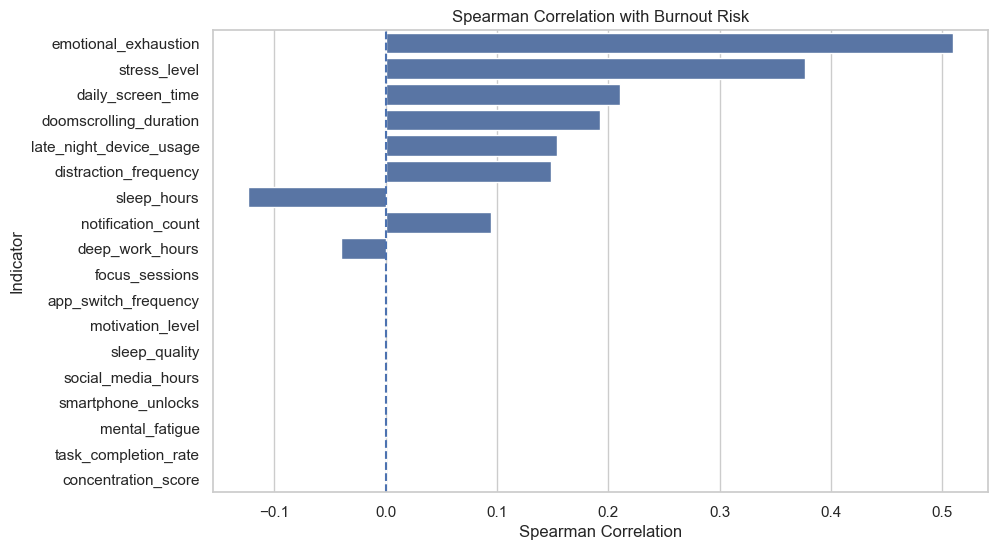

In [9]:
# Visualize Spearman correlation with burnout_risk

if not burnout_correlation.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=burnout_correlation,
        x="spearman_correlation",
        y="indicator"
    )
    plt.title("Spearman Correlation with Burnout Risk")
    plt.xlabel("Spearman Correlation")
    plt.ylabel("Indicator")
    plt.axvline(0, linestyle="--")
    plt.show()

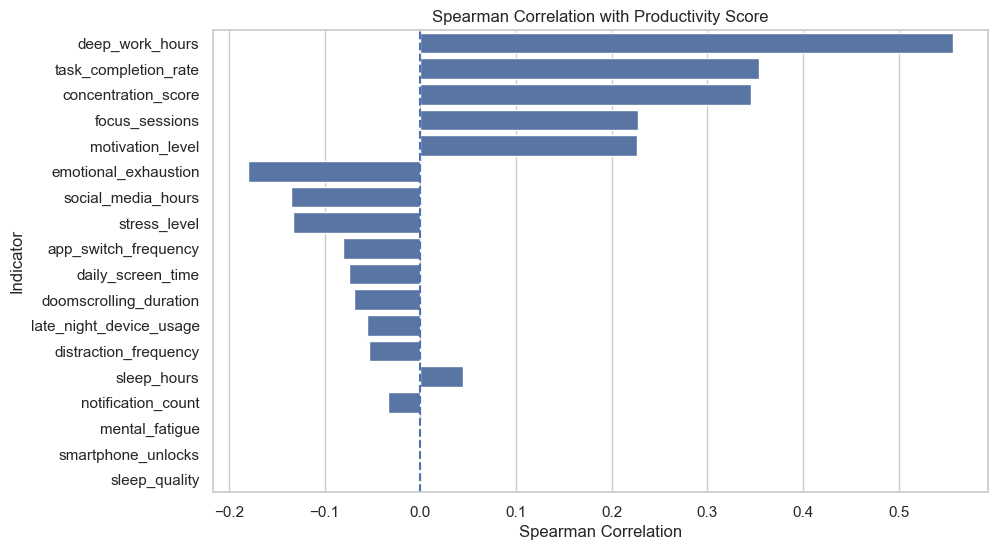

In [10]:
# Visualize Spearman correlation with productivity_score

if not productivity_correlation.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=productivity_correlation,
        x="spearman_correlation",
        y="indicator"
    )
    plt.title("Spearman Correlation with Productivity Score")
    plt.xlabel("Spearman Correlation")
    plt.ylabel("Indicator")
    plt.axvline(0, linestyle="--")
    plt.show()

## 4. Statistical Significance Validation

Phần này đánh giá bằng chứng thống kê của từng chỉ báo.

Vì nhiều biến nghiên cứu là numeric, notebook sử dụng hai hướng:

1. Pearson/Spearman p-value cho biến numeric.
2. ANOVA cho biến categorical/context variables đối với target numeric.

Các chỉ số sử dụng:

- p-value
- Effect Size
- Eta-squared cho ANOVA

Lưu ý:

p-value cho biết bằng chứng thống kê, còn effect size cho biết mức độ ảnh hưởng thực tế.

In [11]:
# Evidence strength helper functions

def classify_correlation_strength(abs_corr):
    if abs_corr >= 0.50:
        return "Strong"
    elif abs_corr >= 0.30:
        return "Moderate"
    elif abs_corr >= 0.10:
        return "Weak"
    else:
        return "Very Weak"


def classify_p_value(p_value):
    if pd.isna(p_value):
        return "Not Available"
    elif p_value < 0.001:
        return "Highly Significant"
    elif p_value < 0.01:
        return "Significant"
    elif p_value < 0.05:
        return "Marginally Significant"
    else:
        return "Not Significant"


def classify_eta_squared(eta_sq):
    if pd.isna(eta_sq):
        return "Not Available"
    elif eta_sq >= 0.14:
        return "Large"
    elif eta_sq >= 0.06:
        return "Medium"
    elif eta_sq >= 0.01:
        return "Small"
    else:
        return "Very Small"

In [12]:
# ANOVA validation for categorical features

anova_results = []

for feature in available_categorical_features:
    for target in available_targets:
        temp_df = df[[feature, target]].dropna()
        
        if temp_df[feature].nunique() < 2:
            continue
        
        try:
            model = ols(
                f"{target} ~ C({feature})",
                data=temp_df
            ).fit()
            
            anova_table = sm.stats.anova_lm(model, typ=2)
            
            ss_between = anova_table["sum_sq"].iloc[0]
            ss_total = anova_table["sum_sq"].sum()
            eta_squared = ss_between / ss_total if ss_total != 0 else np.nan
            
            p_value = anova_table["PR(>F)"].iloc[0]
            f_statistic = anova_table["F"].iloc[0]
            
            anova_results.append({
                "indicator": feature,
                "target": target,
                "test": "ANOVA",
                "f_statistic": f_statistic,
                "p_value": p_value,
                "eta_squared": eta_squared,
                "effect_size_strength": classify_eta_squared(eta_squared),
                "significance": classify_p_value(p_value)
            })
        
        except Exception as error:
            anova_results.append({
                "indicator": feature,
                "target": target,
                "test": "ANOVA",
                "f_statistic": np.nan,
                "p_value": np.nan,
                "eta_squared": np.nan,
                "effect_size_strength": "Error",
                "significance": str(error)
            })

anova_validation = pd.DataFrame(anova_results)

display(anova_validation)

,indicator,target,test,f_statistic,p_value,eta_squared,effect_size_strength,significance
0,work_mode,burnout_risk,ANOVA,0.024327,0.975967,9.730613e-09,Very Small,Not Significant
1,work_mode,productivity_score,ANOVA,0.658338,0.517711,2.633351e-07,Very Small,Not Significant
2,device_usage_type,burnout_risk,ANOVA,0.221832,0.801050,8.873297e-08,Very Small,Not Significant
3,device_usage_type,productivity_score,ANOVA,0.599804,0.548919,2.399218e-07,Very Small,Not Significant


## 5. Feature Ranking

Feature Ranking được thực hiện theo hai hướng:

1. Ranking theo correlation với `burnout_risk`.
2. Ranking theo correlation với `productivity_score`.
3. Ranking theo bằng chứng thống kê tổng hợp.

Lưu ý:

Ranking ở đây không phải Feature Selection cho Machine Learning.

Đây là ranking phục vụ đánh giá chỉ báo nghiên cứu.

In [13]:
# Ranking by Spearman correlation with burnout_risk

burnout_feature_ranking = burnout_correlation.copy()

if not burnout_feature_ranking.empty:
    burnout_feature_ranking["correlation_strength"] = burnout_feature_ranking[
        "absolute_spearman"
    ].apply(classify_correlation_strength)
    
    burnout_feature_ranking["significance"] = burnout_feature_ranking[
        "spearman_p_value"
    ].apply(classify_p_value)
    
    burnout_feature_ranking = burnout_feature_ranking.sort_values(
        by="absolute_spearman",
        ascending=False
    )
    
    display(burnout_feature_ranking[
        [
            "indicator",
            "spearman_correlation",
            "spearman_p_value",
            "correlation_strength",
            "significance"
        ]
    ])

,indicator,spearman_correlation,spearman_p_value,correlation_strength,significance
0,emotional_exhaustion,0.509398,0.000000,Strong,Highly Significant
2,stress_level,0.376978,0.000000,Moderate,Highly Significant
6,daily_screen_time,0.210659,0.000000,Weak,Highly Significant
10,doomscrolling_duration,0.192633,0.000000,Weak,Highly Significant
12,late_night_device_usage,0.154407,0.000000,Weak,Highly Significant
22,distraction_frequency,0.148415,0.000000,Weak,Highly Significant
32,sleep_hours,-0.123721,0.000000,Weak,Highly Significant
14,notification_count,0.094314,0.000000,Very Weak,Highly Significant
26,deep_work_hours,-0.040238,0.000000,Very Weak,Highly Significant
24,focus_sessions,0.001006,0.024549,Very Weak,Marginally Significant


In [14]:
# Ranking by Spearman correlation with productivity_score

productivity_feature_ranking = productivity_correlation.copy()

if not productivity_feature_ranking.empty:
    productivity_feature_ranking["correlation_strength"] = productivity_feature_ranking[
        "absolute_spearman"
    ].apply(classify_correlation_strength)
    
    productivity_feature_ranking["significance"] = productivity_feature_ranking[
        "spearman_p_value"
    ].apply(classify_p_value)
    
    productivity_feature_ranking = productivity_feature_ranking.sort_values(
        by="absolute_spearman",
        ascending=False
    )
    
    display(productivity_feature_ranking[
        [
            "indicator",
            "spearman_correlation",
            "spearman_p_value",
            "correlation_strength",
            "significance"
        ]
    ])

,indicator,spearman_correlation,spearman_p_value,correlation_strength,significance
27,deep_work_hours,0.556077,0.000000,Strong,Highly Significant
29,task_completion_rate,0.353570,0.000000,Moderate,Highly Significant
21,concentration_score,0.345042,0.000000,Moderate,Highly Significant
25,focus_sessions,0.227663,0.000000,Weak,Highly Significant
31,motivation_level,0.226453,0.000000,Weak,Highly Significant
1,emotional_exhaustion,-0.180020,0.000000,Weak,Highly Significant
9,social_media_hours,-0.135305,0.000000,Weak,Highly Significant
3,stress_level,-0.133452,0.000000,Weak,Highly Significant
19,app_switch_frequency,-0.081262,0.000000,Very Weak,Highly Significant
7,daily_screen_time,-0.074910,0.000000,Very Weak,Highly Significant


## 6. Feature Stability Assessment

Phần này phân loại chỉ báo thành ba nhóm:

- Strong Indicators
- Moderate Indicators
- Weak Indicators

Tiêu chí đánh giá dựa trên:

- Độ lớn correlation.
- p-value.
- Sự nhất quán giữa Pearson và Spearman.
- Mối liên hệ với ít nhất một target nghiên cứu.

Đây là đánh giá trước DBI, chưa phải điểm DBI chính thức.

In [15]:
# Build numeric feature validation summary

numeric_summary_rows = []

for feature in available_numeric_features:
    feature_corr = correlation_validation[
        correlation_validation["indicator"] == feature
    ]
    
    if feature_corr.empty:
        continue
    
    burnout_row = feature_corr[feature_corr["target"] == "burnout_risk"]
    productivity_row = feature_corr[feature_corr["target"] == "productivity_score"]
    
    burnout_corr_value = (
        burnout_row["spearman_correlation"].iloc[0]
        if not burnout_row.empty else np.nan
    )
    
    burnout_p_value = (
        burnout_row["spearman_p_value"].iloc[0]
        if not burnout_row.empty else np.nan
    )
    
    productivity_corr_value = (
        productivity_row["spearman_correlation"].iloc[0]
        if not productivity_row.empty else np.nan
    )
    
    productivity_p_value = (
        productivity_row["spearman_p_value"].iloc[0]
        if not productivity_row.empty else np.nan
    )
    
    max_abs_corr = np.nanmax([
        abs(burnout_corr_value),
        abs(productivity_corr_value)
    ])
    
    min_p_value = np.nanmin([
        burnout_p_value,
        productivity_p_value
    ])
    
    numeric_summary_rows.append({
        "indicator": feature,
        "indicator_type": "Numeric",
        "burnout_correlation": burnout_corr_value,
        "burnout_p_value": burnout_p_value,
        "productivity_correlation": productivity_corr_value,
        "productivity_p_value": productivity_p_value,
        "max_absolute_correlation": max_abs_corr,
        "best_p_value": min_p_value
    })

numeric_validation_summary = pd.DataFrame(numeric_summary_rows)

display(numeric_validation_summary)

,indicator,indicator_type,burnout_correlation,burnout_p_value,productivity_correlation,productivity_p_value,max_absolute_correlation,best_p_value
0,emotional_exhaustion,Numeric,0.509398,0.000000,-0.180020,0.000000,0.509398,0.000000
1,stress_level,Numeric,0.376978,0.000000,-0.133452,0.000000,0.376978,0.000000
2,mental_fatigue,Numeric,-0.000126,0.778587,0.000508,0.256024,0.000508,0.256024
3,daily_screen_time,Numeric,0.210659,0.000000,-0.074910,0.000000,0.210659,0.000000
4,social_media_hours,Numeric,-0.000176,0.693380,-0.135305,0.000000,0.135305,0.000000
5,doomscrolling_duration,Numeric,0.192633,0.000000,-0.069595,0.000000,0.192633,0.000000
6,late_night_device_usage,Numeric,0.154407,0.000000,-0.055263,0.000000,0.154407,0.000000
7,notification_count,Numeric,0.094314,0.000000,-0.033552,0.000000,0.094314,0.000000
8,smartphone_unlocks,Numeric,-0.000173,0.699025,0.000237,0.596682,0.000237,0.596682
9,app_switch_frequency,Numeric,-0.000774,0.083660,-0.081262,0.000000,0.081262,0.000000


In [16]:
# Add categorical validation summary from ANOVA

categorical_summary_rows = []

for feature in available_categorical_features:
    feature_anova = anova_validation[
        anova_validation["indicator"] == feature
    ]
    
    if feature_anova.empty:
        continue
    
    best_eta = feature_anova["eta_squared"].max()
    best_p = feature_anova["p_value"].min()
    
    categorical_summary_rows.append({
        "indicator": feature,
        "indicator_type": "Categorical",
        "burnout_correlation": np.nan,
        "burnout_p_value": np.nan,
        "productivity_correlation": np.nan,
        "productivity_p_value": np.nan,
        "max_absolute_correlation": best_eta,
        "best_p_value": best_p
    })

categorical_validation_summary = pd.DataFrame(categorical_summary_rows)

feature_validation_base = pd.concat(
    [
        numeric_validation_summary,
        categorical_validation_summary
    ],
    ignore_index=True
)

display(feature_validation_base)

,indicator,indicator_type,burnout_correlation,burnout_p_value,productivity_correlation,productivity_p_value,max_absolute_correlation,best_p_value
0,emotional_exhaustion,Numeric,0.509398,0.000000,-0.180020,0.000000,5.093981e-01,0.000000
1,stress_level,Numeric,0.376978,0.000000,-0.133452,0.000000,3.769779e-01,0.000000
2,mental_fatigue,Numeric,-0.000126,0.778587,0.000508,0.256024,5.079626e-04,0.256024
3,daily_screen_time,Numeric,0.210659,0.000000,-0.074910,0.000000,2.106594e-01,0.000000
4,social_media_hours,Numeric,-0.000176,0.693380,-0.135305,0.000000,1.353051e-01,0.000000
5,doomscrolling_duration,Numeric,0.192633,0.000000,-0.069595,0.000000,1.926333e-01,0.000000
6,late_night_device_usage,Numeric,0.154407,0.000000,-0.055263,0.000000,1.544067e-01,0.000000
7,notification_count,Numeric,0.094314,0.000000,-0.033552,0.000000,9.431350e-02,0.000000
8,smartphone_unlocks,Numeric,-0.000173,0.699025,0.000237,0.596682,2.366559e-04,0.596682
9,app_switch_frequency,Numeric,-0.000774,0.083660,-0.081262,0.000000,8.126183e-02,0.000000


In [17]:
# Classify evidence strength and recommendation

def classify_evidence_strength(row):
    effect_value = row["max_absolute_correlation"]
    p_value = row["best_p_value"]
    
    if pd.isna(effect_value) or pd.isna(p_value):
        return "Insufficient Evidence"
    
    if effect_value >= 0.50 and p_value < 0.05:
        return "Strong"
    elif effect_value >= 0.30 and p_value < 0.05:
        return "Moderate"
    elif effect_value >= 0.10 and p_value < 0.05:
        return "Weak"
    else:
        return "Very Weak"


def generate_recommendation(evidence_strength):
    if evidence_strength == "Strong":
        return "Retain as core indicator"
    elif evidence_strength == "Moderate":
        return "Retain as candidate indicator"
    elif evidence_strength == "Weak":
        return "Review with theoretical support"
    elif evidence_strength == "Very Weak":
        return "Consider removing or re-evaluating"
    else:
        return "Insufficient evidence for decision"


feature_validation_base["evidence_strength"] = feature_validation_base.apply(
    classify_evidence_strength,
    axis=1
)

feature_validation_base["recommendation"] = feature_validation_base[
    "evidence_strength"
].apply(generate_recommendation)

display(feature_validation_base.sort_values(
    by=["evidence_strength", "max_absolute_correlation"],
    ascending=[True, False]
))

,indicator,indicator_type,burnout_correlation,burnout_p_value,productivity_correlation,productivity_p_value,max_absolute_correlation,best_p_value,evidence_strength,recommendation
1,stress_level,Numeric,0.376978,0.000000,-0.133452,0.000000,3.769779e-01,0.000000,Moderate,Retain as candidate indicator
14,task_completion_rate,Numeric,0.000017,0.969615,0.353570,0.000000,3.535705e-01,0.000000,Moderate,Retain as candidate indicator
10,concentration_score,Numeric,0.000009,0.984483,0.345042,0.000000,3.450421e-01,0.000000,Moderate,Retain as candidate indicator
13,deep_work_hours,Numeric,-0.040238,0.000000,0.556077,0.000000,5.560769e-01,0.000000,Strong,Retain as core indicator
0,emotional_exhaustion,Numeric,0.509398,0.000000,-0.180020,0.000000,5.093981e-01,0.000000,Strong,Retain as core indicator
7,notification_count,Numeric,0.094314,0.000000,-0.033552,0.000000,9.431350e-02,0.000000,Very Weak,Consider removing or re-evaluating
9,app_switch_frequency,Numeric,-0.000774,0.083660,-0.081262,0.000000,8.126183e-02,0.000000,Very Weak,Consider removing or re-evaluating
2,mental_fatigue,Numeric,-0.000126,0.778587,0.000508,0.256024,5.079626e-04,0.256024,Very Weak,Consider removing or re-evaluating
8,smartphone_unlocks,Numeric,-0.000173,0.699025,0.000237,0.596682,2.366559e-04,0.596682,Very Weak,Consider removing or re-evaluating
17,sleep_quality,Numeric,-0.000204,0.648956,0.000015,0.972961,2.035775e-04,0.648956,Very Weak,Consider removing or re-evaluating


## 7. Feature Validation Summary Table

Bảng cuối cùng gồm:

| Indicator | Correlation | p-value | Evidence Strength | Recommendation |

Trong đó:

- Correlation: lấy giá trị liên hệ mạnh nhất với `burnout_risk` hoặc `productivity_score`.
- p-value: lấy p-value tốt nhất từ correlation hoặc ANOVA.
- Evidence Strength: phân loại bằng chứng.
- Recommendation: khuyến nghị sử dụng trong DBI Framework.

In [18]:
# Final feature validation summary table

feature_validation_summary = feature_validation_base.copy()

feature_validation_summary = feature_validation_summary.rename(columns={
    "indicator": "Indicator",
    "max_absolute_correlation": "Correlation",
    "best_p_value": "p-value",
    "evidence_strength": "Evidence Strength",
    "recommendation": "Recommendation"
})

feature_validation_summary = feature_validation_summary[
    [
        "Indicator",
        "Correlation",
        "p-value",
        "Evidence Strength",
        "Recommendation"
    ]
].sort_values(
    by="Correlation",
    ascending=False
)

display(feature_validation_summary)

,Indicator,Correlation,p-value,Evidence Strength,Recommendation
13,deep_work_hours,5.560769e-01,0.000000,Strong,Retain as core indicator
0,emotional_exhaustion,5.093981e-01,0.000000,Strong,Retain as core indicator
1,stress_level,3.769779e-01,0.000000,Moderate,Retain as candidate indicator
14,task_completion_rate,3.535705e-01,0.000000,Moderate,Retain as candidate indicator
10,concentration_score,3.450421e-01,0.000000,Moderate,Retain as candidate indicator
12,focus_sessions,2.276629e-01,0.000000,Weak,Review with theoretical support
15,motivation_level,2.264535e-01,0.000000,Weak,Review with theoretical support
3,daily_screen_time,2.106594e-01,0.000000,Weak,Review with theoretical support
5,doomscrolling_duration,1.926333e-01,0.000000,Weak,Review with theoretical support
6,late_night_device_usage,1.544067e-01,0.000000,Weak,Review with theoretical support


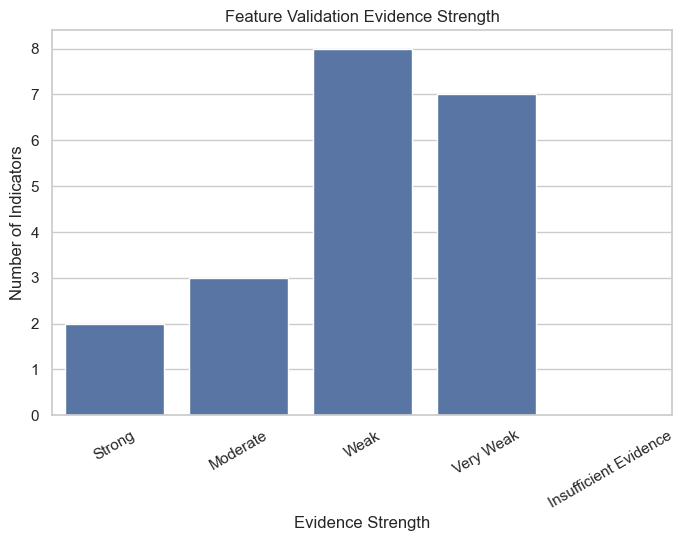

In [19]:
# Visualize evidence strength

plt.figure(figsize=(8, 5))

sns.countplot(
    data=feature_validation_summary,
    x="Evidence Strength",
    order=[
        "Strong",
        "Moderate",
        "Weak",
        "Very Weak",
        "Insufficient Evidence"
    ]
)

plt.title("Feature Validation Evidence Strength")
plt.xlabel("Evidence Strength")
plt.ylabel("Number of Indicators")
plt.xticks(rotation=30)
plt.show()

## 8. Strong, Moderate, and Weak Indicators

Phần này tách các chỉ báo thành ba nhóm để phục vụ bước xây dựng DBI Framework.

Lưu ý:

Đây là kết quả validation sơ bộ, chưa phải DBI chính thức.

In [20]:
strong_indicators = feature_validation_summary[
    feature_validation_summary["Evidence Strength"] == "Strong"
]

moderate_indicators = feature_validation_summary[
    feature_validation_summary["Evidence Strength"] == "Moderate"
]

weak_indicators = feature_validation_summary[
    feature_validation_summary["Evidence Strength"].isin([
        "Weak",
        "Very Weak",
        "Insufficient Evidence"
    ])
]

print("Strong Indicators")
display(strong_indicators)

print("Moderate Indicators")
display(moderate_indicators)

print("Weak / Re-evaluation Indicators")
display(weak_indicators)

Strong Indicators


,Indicator,Correlation,p-value,Evidence Strength,Recommendation
13,deep_work_hours,0.556077,0.0,Strong,Retain as core indicator
0,emotional_exhaustion,0.509398,0.0,Strong,Retain as core indicator


Moderate Indicators


,Indicator,Correlation,p-value,Evidence Strength,Recommendation
1,stress_level,0.376978,0.0,Moderate,Retain as candidate indicator
14,task_completion_rate,0.353570,0.0,Moderate,Retain as candidate indicator
10,concentration_score,0.345042,0.0,Moderate,Retain as candidate indicator


Weak / Re-evaluation Indicators


,Indicator,Correlation,p-value,Evidence Strength,Recommendation
12,focus_sessions,2.276629e-01,0.000000,Weak,Review with theoretical support
15,motivation_level,2.264535e-01,0.000000,Weak,Review with theoretical support
3,daily_screen_time,2.106594e-01,0.000000,Weak,Review with theoretical support
5,doomscrolling_duration,1.926333e-01,0.000000,Weak,Review with theoretical support
6,late_night_device_usage,1.544067e-01,0.000000,Weak,Review with theoretical support
11,distraction_frequency,1.484146e-01,0.000000,Weak,Review with theoretical support
4,social_media_hours,1.353051e-01,0.000000,Weak,Review with theoretical support
16,sleep_hours,1.237210e-01,0.000000,Weak,Review with theoretical support
7,notification_count,9.431350e-02,0.000000,Very Weak,Consider removing or re-evaluating
9,app_switch_frequency,8.126183e-02,0.000000,Very Weak,Consider removing or re-evaluating


## 9. Research Findings

Phần này tổng hợp các nhận xét học thuật từ Feature Validation.

Các nhận xét này phục vụ:

- Xây dựng Digital Burnout Indicator Framework.
- Chuẩn bị giả thuyết cho Modeling.
- So sánh với Vietnam Dataset ở giai đoạn sau.

In [21]:
# Generate research findings

research_findings = [
    "1. Feature Validation cho thấy các chỉ báo không nên được giữ chỉ vì xuất hiện trong dataset; cần đánh giá bằng cả correlation và statistical evidence.",
    "2. Các biến thuộc nhóm Burnout Symptoms thường được kỳ vọng có liên hệ trực tiếp với burnout_risk và cần được ưu tiên kiểm chứng trong DBI.",
    "3. Digital Exposure là nhóm chỉ báo quan trọng vì phản ánh hành vi sử dụng thiết bị, nhưng từng biến cần được đánh giá riêng theo độ mạnh correlation.",
    "4. Các chỉ báo như daily_screen_time, doomscrolling_duration hoặc late_night_device_usage cần được xem xét không chỉ theo p-value mà còn theo ý nghĩa hành vi.",
    "5. Cognitive Performance có thể phản ánh hệ quả chức năng của Digital Burnout thông qua concentration, motivation và productivity.",
    "6. Sleep & Recovery có vai trò tiềm năng như nhóm chỉ báo phục hồi hoặc yếu tố bảo vệ trong DBI.",
    "7. Context Variables như work_mode và device_usage_type không nên được xử lý như chỉ báo cường độ, mà nên dùng để phân tích khác biệt nhóm.",
    "8. p-value có thể rất nhỏ trong dataset lớn, vì vậy effect size hoặc correlation strength cần được xem xét cùng lúc.",
    "9. Các chỉ báo có correlation yếu nhưng có nền tảng lý thuyết mạnh không nên bị loại bỏ ngay mà nên đưa vào nhóm cần xem xét thêm.",
    "10. Feature Ranking trong notebook này không phải Feature Selection cho Machine Learning, mà là ranking phục vụ xây dựng framework nghiên cứu.",
    "11. Các chỉ báo Strong và Moderate có thể được ưu tiên đưa vào bước DBI Development.",
    "12. Các chỉ báo Weak cần được kiểm tra thêm khi có Vietnam Dataset để đánh giá tính ổn định theo bối cảnh."
]

for finding in research_findings:
    print(finding)

1. Feature Validation cho thấy các chỉ báo không nên được giữ chỉ vì xuất hiện trong dataset; cần đánh giá bằng cả correlation và statistical evidence.
2. Các biến thuộc nhóm Burnout Symptoms thường được kỳ vọng có liên hệ trực tiếp với burnout_risk và cần được ưu tiên kiểm chứng trong DBI.
3. Digital Exposure là nhóm chỉ báo quan trọng vì phản ánh hành vi sử dụng thiết bị, nhưng từng biến cần được đánh giá riêng theo độ mạnh correlation.
4. Các chỉ báo như daily_screen_time, doomscrolling_duration hoặc late_night_device_usage cần được xem xét không chỉ theo p-value mà còn theo ý nghĩa hành vi.
5. Cognitive Performance có thể phản ánh hệ quả chức năng của Digital Burnout thông qua concentration, motivation và productivity.
6. Sleep & Recovery có vai trò tiềm năng như nhóm chỉ báo phục hồi hoặc yếu tố bảo vệ trong DBI.
7. Context Variables như work_mode và device_usage_type không nên được xử lý như chỉ báo cường độ, mà nên dùng để phân tích khác biệt nhóm.
8. p-value có thể rất nhỏ tron

## 10. Export Validated Indicators

Phần này tạo file:

`validated_indicators.csv`

File này có thể được sử dụng làm đầu vào cho notebook xây dựng DBI Framework.

Lưu ý:

Nếu chỉ muốn xem code và chưa muốn xuất file, có thể không chạy cell này.

In [22]:
# Export validated indicators

validated_output_path = "../../data/processed/international_dataset/validated_indicators.csv"

feature_validation_summary.to_csv(
    validated_output_path,
    index=False
)

print(f"Validated indicators saved to: {validated_output_path}")

Validated indicators saved to: ../../data/processed/international_dataset/validated_indicators.csv


## 11. Notebook Output Summary

Output của notebook:

1. Research Features Review  
2. Pearson Correlation Results  
3. Spearman Correlation Results  
4. ANOVA Results for Context Variables  
5. Feature Ranking  
6. Feature Stability Assessment  
7. Feature Validation Summary Table  
8. Research Findings  
9. validated_indicators.csv  

Các output này sẽ được sử dụng cho:

- DBI Framework Development
- Modeling Preparation
- Cross-Dataset Comparative Analysis

In [23]:
notebook_output_summary = pd.DataFrame({
    "output": [
        "feature_review",
        "correlation_validation",
        "anova_validation",
        "burnout_feature_ranking",
        "productivity_feature_ranking",
        "feature_validation_summary",
        "research_findings",
        "validated_indicators.csv"
    ],
    "purpose": [
        "Check availability of research indicators",
        "Assess Pearson and Spearman relationships",
        "Assess context variable effects using ANOVA",
        "Rank indicators by relationship with burnout_risk",
        "Rank indicators by relationship with productivity_score",
        "Summarize validation evidence and recommendations",
        "Provide academic interpretation",
        "Store validated indicators for DBI development"
    ],
    "next_stage": [
        "Feature Validation",
        "DBI Development",
        "DBI Development",
        "DBI Development",
        "Modeling Preparation",
        "DBI Development",
        "Research Discussion",
        "DBI Framework"
    ]
})

display(notebook_output_summary)

,output,purpose,next_stage
0,feature_review,Check availability of research indicators,Feature Validation
1,correlation_validation,Assess Pearson and Spearman relationships,DBI Development
2,anova_validation,Assess context variable effects using ANOVA,DBI Development
3,burnout_feature_ranking,Rank indicators by relationship with burnout_risk,DBI Development
4,productivity_feature_ranking,Rank indicators by relationship with productiv...,Modeling Preparation
5,feature_validation_summary,Summarize validation evidence and recommendations,DBI Development
6,research_findings,Provide academic interpretation,Research Discussion
7,validated_indicators.csv,Store validated indicators for DBI development,DBI Framework
